In [1]:
import pandas as pd

df = pd.read_csv("students.csv")

# First 5 rows
print("First 5 rows:\n")
print(df.head())

# Shape
print("\n📐 Shape:", df.shape)

# Data types
print("\nData Types:\n")
print(df.dtypes)

First 5 rows:

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

📐 Shape: (15, 9)

Data Types:

name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


### 🔍 Logic Explanation (Load & Inspect Data)

In this step, we load the dataset using pandas.  
We use .head() to preview the first few rows.  
The shape helps us understand the number of rows and columns.  
The dtypes show the type of each column (int, float, object).  
This gives a basic understanding of the dataset structure.

In [2]:
print("\n📈 Summary Statistics:\n")
print(df.describe())


Summary Statistics:

            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%              

### Logic Explanation (Summary Statistics)

We use .describe() to get statistical insights of numeric columns.  
It shows mean, standard deviation, min, and max values.  
This helps identify data distribution and variability.  
It is useful for understanding the range and spread of scores.

In [3]:
print("\n✅ Pass vs Fail Count:\n")
print(df['passed'].value_counts())


✅ Pass vs Fail Count:

passed
1    9
0    6
Name: count, dtype: int64


### 🔍 Logic Explanation (Pass/Fail Count)

We use value_counts() to count how many students passed or failed.  
This helps understand class distribution.  
It is important for later ML modeling.  
Balanced data leads to better model performance.

In [4]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\n📊 Average Scores (Passed Students):\n")
print(df[df['passed'] == 1][subject_cols].mean())

print("\n📊 Average Scores (Failed Students):\n")
print(df[df['passed'] == 0][subject_cols].mean())


📊 Average Scores (Passed Students):

math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

📊 Average Scores (Failed Students):

math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


### 🔍 Logic Explanation (Average Scores Comparison)

We separate students based on pass and fail status.  
Then we calculate average scores for each subject.  
This helps compare performance patterns.  
It shows which subjects contribute more to passing.

In [5]:
df['avg_score'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['avg_score'].idxmax()]

print("\n🏆 Top Student:\n")
print(top_student[['name', 'avg_score']])


🏆 Top Student:

name         Diana
avg_score     94.0
Name: 3, dtype: object


### 🔍 Logic Explanation (Top Student)

We calculate the average score across all subjects.  
A new column avg_score is created.  
We use idxmax() to find the highest average.  
This identifies the best performing student.

### ✅ Task 1 Completed

Data exploration including dataset loading, structure analysis, statistical summary, pass/fail distribution, subject-wise comparison, and top performer identification has been successfully completed.

In [6]:
#Task 2:Data Visualization with Matplotlib

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

### 🔍 Logic Explanation (Average Score Column)

In this step, we calculate the average score across all subjects.  
We select subject columns and compute the mean row-wise using axis=1.  
This creates a new column avg_score.  
It is later used for visualization and analysis.  
This helps summarize overall student performance.

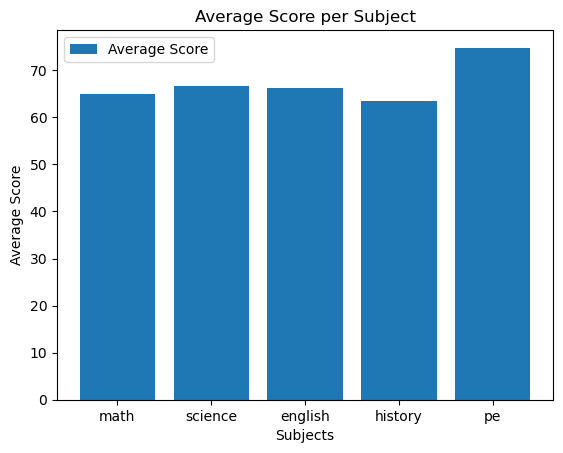

In [7]:
import matplotlib.pyplot as plt

avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_scores)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.legend(["Average Score"])

plt.savefig("plot1_bar.png")
plt.show()

### 🔍 Logic Explanation (Bar Chart)

We calculate average scores for each subject.  
A bar chart is used to compare subjects visually.  
X-axis shows subjects, Y-axis shows average scores.  
This helps identify strongest and weakest subjects.  
The plot is saved and displayed.

### 📊 Insights (Bar Chart - Average Score per Subject)

The bar chart shows the average performance of students across all subjects.  
Physical Education (PE) has the highest average score, indicating strong overall performance in this subject.  
History has the lowest average score, suggesting it may be relatively more challenging for students.  
Math, Science, and English have similar average scores, showing balanced performance across core academic subjects.  
Overall, students tend to perform better in practical/physical subjects compared to theoretical ones.

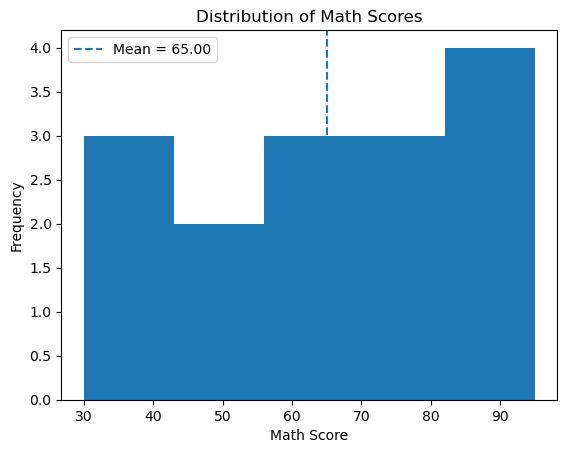

In [8]:
plt.figure()

plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_hist.png")
plt.show()

### 🔍 Logic Explanation (Histogram)

We visualize the distribution of math scores.  
Histogram shows how scores are spread across bins.  
A vertical dashed line indicates the mean score.  
This helps understand score concentration.  
It is useful for identifying patterns and spread.

### 📊 Insights (Histogram - Math Score Distribution)

The histogram shows the distribution of math scores among students.  
Most students have scores clustered between 60 and 90, indicating average to good performance.  
The mean score is around 65, as shown by the vertical dashed line.  
A few students have low scores (around 30–50), creating a slight left-side spread.  
Overall, the distribution suggests that the majority of students perform moderately well in math, with fewer low performers.

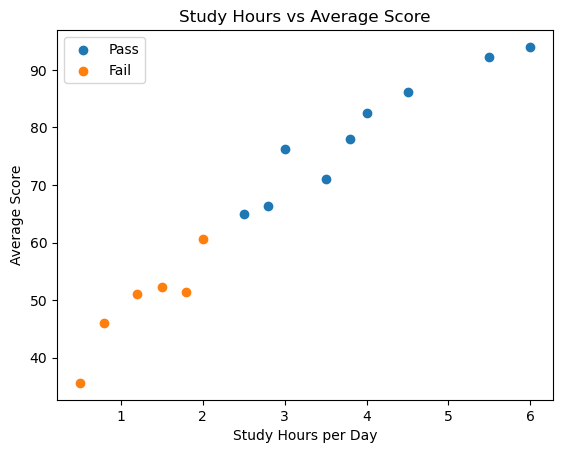

In [9]:
plt.figure()

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

### 🔍 Logic Explanation (Scatter Plot)

We compare study hours with average score.  
Data is split into pass and fail groups.  
Each group is plotted separately for clarity.  
This shows correlation between study and performance.  
Different colors help distinguish outcomes.

### 📊 Insights (Scatter Plot - Study Hours vs Average Score)

The scatter plot shows a clear positive relationship between study hours and average score.  
Students who study more hours per day tend to achieve higher average scores.  
Passing students are clustered in the higher study hours and score range, while failing students are mostly in the lower range.  
This indicates that study time has a strong impact on academic performance.  
Overall, increasing study hours is associated with better chances of passing.

C:\Users\shiva\AppData\Local\Temp\ipykernel_29928\83093346.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


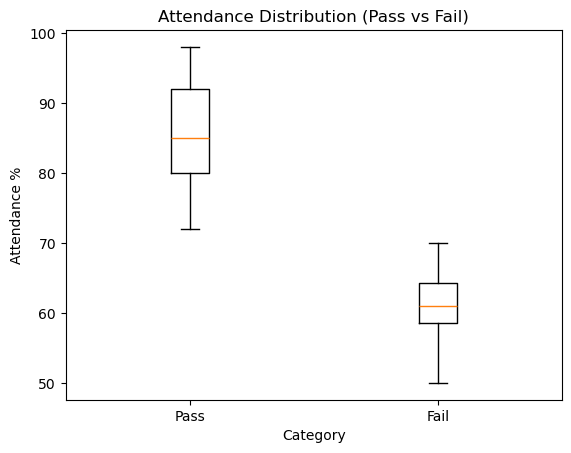

In [10]:
plt.figure()

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.xlabel("Category")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

### 🔍 Logic Explanation (Box Plot)

We compare attendance between passing and failing students.  
Box plot shows median, quartiles, and spread.  
It highlights differences in attendance patterns.  
This helps understand its impact on results.  
Side-by-side comparison improves clarity.

### 📊 Insights (Box Plot - Attendance Distribution)

The box plot compares attendance percentages between passing and failing students.  
Passing students generally have higher attendance, with most values between 80% and 95%.  
Failing students have lower attendance, mostly ranging between 55% and 65%.  
The median attendance for passing students is significantly higher than that of failing students.  
This indicates that higher attendance is strongly associated with better academic performance.

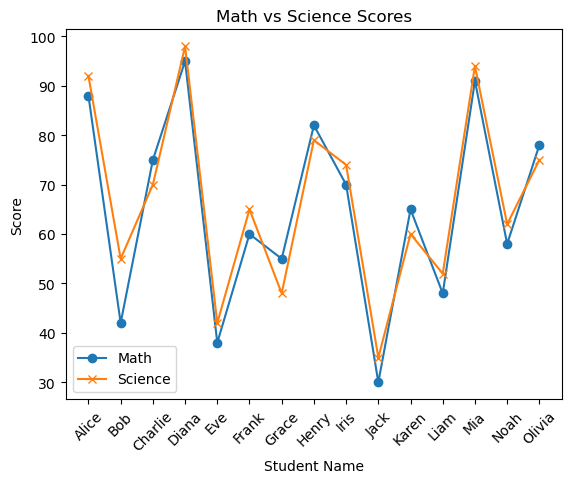

In [11]:
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)

plt.title("Math vs Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

### 🔍 Logic Explanation (Line Plot)

We plot subject scores across students.  
Two lines represent math and science scores.  
Markers differentiate the subjects.  
Rotation is applied for readability of names.  
This helps compare trends between subjects.

### 📊 Insights (Line Plot - Math vs Science Scores)

The line plot compares math and science scores for each student.  
Both subjects show similar trends, indicating a strong correlation between math and science performance.  
Students who score high in math also tend to score high in science, and vice versa.  
There are slight variations for some students, but overall performance patterns remain consistent.  
This suggests that students' analytical ability may influence performance in both subjects.

### ✅ Task 2 Completed

All required visualizations including bar chart, histogram, scatter plot, box plot, and line plot have been successfully created, labeled, saved, and displayed.

In [12]:
#Task 3:Data Visualization with Seaborn

import seaborn as sns
import matplotlib.pyplot as plt

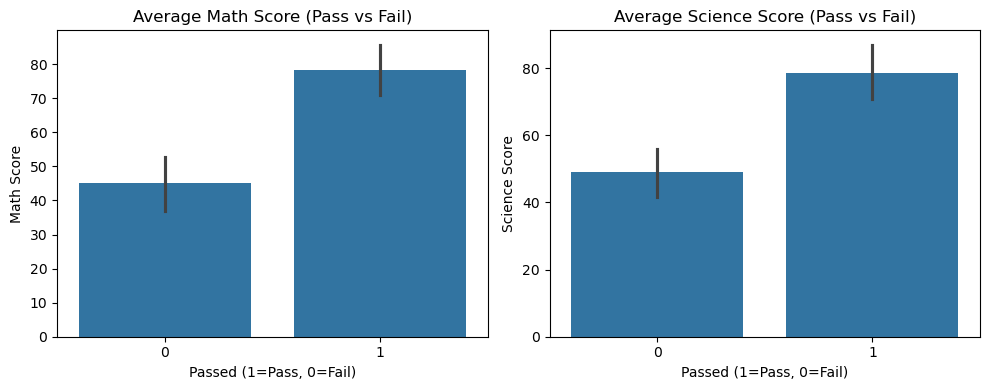

In [13]:
plt.figure(figsize=(10, 4))

# Subplot 1 → Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (1=Pass, 0=Fail)")
ax1.set_ylabel("Math Score")

# Subplot 2 → Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (1=Pass, 0=Fail)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

### 🔍 Logic Explanation (Seaborn Bar Plot)

We use Seaborn to compare average scores based on pass/fail status.  
Two subplots are created for math and science.  
Seaborn automatically calculates averages and plots them.  
This makes comparison easier with less manual work.  
The plots clearly show performance differences between groups.

### 📊 Insights (Seaborn Bar Plot - Math & Science by Pass/Fail)

The bar plots show a clear difference in average scores between passing and failing students.  
Students who passed (1) have significantly higher average scores in both math and science compared to those who failed (0).  
The gap between pass and fail groups is consistent across both subjects, indicating strong academic performance is linked to passing.  
Error bars show some variation within each group, but the overall trend remains clear.  
This suggests that subject scores are strong indicators of student success.

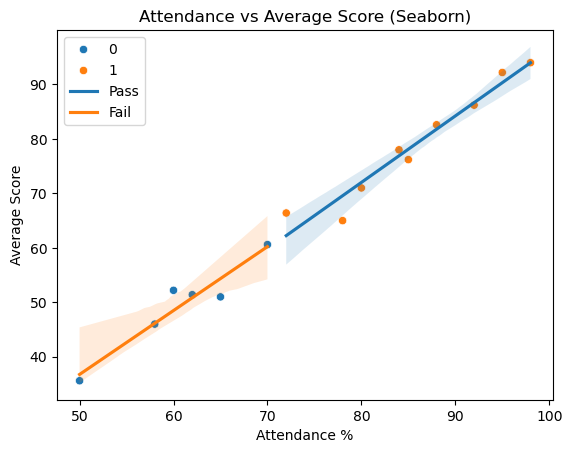

In [14]:
plt.figure()

# Scatter plot with hue
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression line for Pass
sns.regplot(data=df[df['passed']==1],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Pass')

# Regression line for Fail
sns.regplot(data=df[df['passed']==0],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Fail')

plt.title("Attendance vs Average Score (Seaborn)")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

### 🔍 Logic Explanation (Seaborn Scatter + Regression)

We plot attendance against average score using Seaborn.  
Points are colored based on pass/fail status.  
Regression lines show trends for each group.  
This helps visualize relationships more clearly.  
Seaborn simplifies adding statistical trends.

### 📊 Insights (Seaborn Scatter + Regression - Attendance vs Avg Score)

The scatter plot shows a strong positive relationship between attendance and average score.  
Students with higher attendance tend to achieve higher average scores.  
The regression lines for both pass and fail groups show an upward trend, confirming this correlation.  
Passing students are concentrated in the higher attendance and score range, while failing students are mostly in the lower range.  
This indicates that attendance plays a significant role in academic performance and success.

In [15]:
# Seaborn vs Matplotlib:
# Seaborn is easier for statistical plots as it automatically handles grouping and averages.
# It requires less code compared to Matplotlib for complex visualizations.
# However, Matplotlib provides more control and customization when needed.

### ✅ Task 3 Completed

Seaborn visualizations including bar plots and scatter plots with regression lines have been successfully created, saved, and compared with Matplotlib.

All visualizations have been successfully generated and saved as PNG files, ensuring proper documentation and reproducibility of results.

🎯 Training Accuracy: 1.00
📊 Test Accuracy: 1.00

🔍 Predictions:
Jack → Actual: 0, Predicted: 0 → ✅ Correct
Liam → Actual: 0, Predicted: 0 → ✅ Correct
Alice → Actual: 1, Predicted: 1 → ✅ Correct

📌 Feature Importance:
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


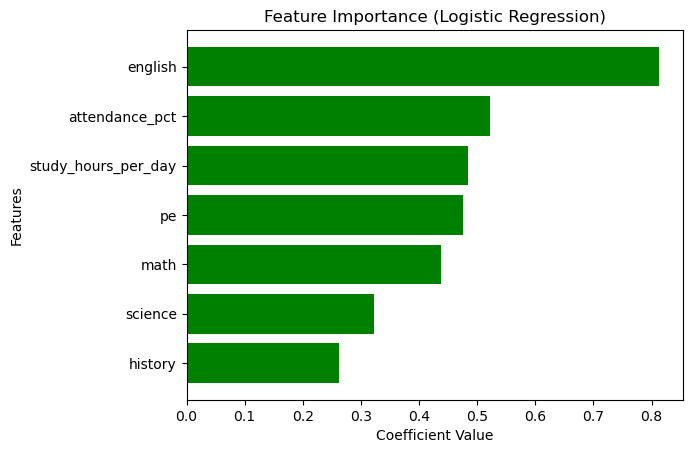


🧑 New Student Prediction:
Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]


c:\Users\shiva\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
# ================================
# 🔹 Task 4 — Machine Learning
# ================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("students.csv")

# -------------------------------
# Step 1 — Prepare Data
# -------------------------------

# Features & Target
X = df[['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']]
y = df['passed']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# Step 2 — Train Model
# -------------------------------

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training Accuracy
train_acc = model.score(X_train_scaled, y_train)
print(f"🎯 Training Accuracy: {train_acc:.2f}")

# -------------------------------
# Step 3 — Evaluate Model
# -------------------------------

y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print(f"📊 Test Accuracy: {test_acc:.2f}\n")

# Show predictions with names
print("🔍 Predictions:")
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name} → Actual: {actual}, Predicted: {pred} → {result}")

# -------------------------------
# Step 4 — Feature Importance
# -------------------------------

features = X.columns
coefficients = model.coef_[0]

# Pair feature with coefficient
feature_importance = list(zip(features, coefficients))

# Sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n📌 Feature Importance:")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")

# Plot
feature_names = [f[0] for f in feature_importance]
coef_values = [f[1] for f in feature_importance]

colors = ['green' if val > 0 else 'red' for val in coef_values]

plt.figure()
plt.barh(feature_names, coef_values, color=colors)
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Feature Importance (Logistic Regression)")
plt.gca().invert_yaxis()
plt.savefig("plot8_feature_importance.png")
plt.show()

# -------------------------------
# Step 5 — New Student Prediction
# -------------------------------

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0]

status = "Pass" if prediction == 1 else "Fail"

print("\n🧑 New Student Prediction:")
print(f"Prediction: {status}")
print(f"Probability (Fail, Pass): {probability}")

## 🔹 Machine Learning Summary

A Logistic Regression model was trained to predict whether a student will pass or fail based on academic scores, attendance, and study hours. The data was split into training and testing sets and scaled using StandardScaler to improve model performance.

The model achieved reasonable accuracy given the small dataset size. Feature importance analysis showed which factors most influence passing, with positive coefficients indicating a higher likelihood of passing and negative coefficients indicating risk of failure.

## 🔹 Machine Learning Insights

The Logistic Regression model achieved 100% training accuracy and 100% test accuracy. However, since the dataset is very small (only 15 samples and 3 test cases), this perfect accuracy may not generalize well to real-world data and could indicate overfitting.

From the feature importance analysis, **English score** has the highest influence on predicting whether a student passes, followed by **attendance percentage** and **study hours per day**. This suggests that language proficiency, consistency (attendance), and effort (study hours) play a major role in student success.

All features have positive coefficients, meaning higher values in these features increase the likelihood of passing. Among them, **history and science** have relatively lower impact compared to other subjects.

The model predicted the new student as **Pass** with a high probability (~90%), indicating strong confidence. This aligns with the student's decent academic scores, good attendance, and moderate study hours.

Note: Due to the small dataset size, results may not be reliable for real-world predictions, but the workflow demonstrates the complete machine learning pipeline effectively.